In [1]:
import math
import numpy as np 
import netCDF4 as nc
import xarray as xr
import thermofeel as tmf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import rioxarray
import glob
from datetime import datetime
import zipfile
import os
import shutil
import gc
import cdsapi

# Upload and prepare the data

In [4]:
# Collect all .nc file paths
nc_files = sorted(glob.glob(r"./0_input/ERA5_grid_cell_data/output/025_alltemps_*.nc"))

# Open and concatenate along time
all_temps = {}
for f in nc_files[:-24]:
    ds = xr.open_mfdataset(f, combine='by_coords').load()
    daily = ds.resample(time="1D").mean()
    all_temps[f]= daily
alltemps = xr.concat(all_temps.values(), dim='time')
print(alltemps)

<xarray.Dataset> Size: 244MB
Dimensions:  (time: 486, lat: 117, lon: 119)
Coordinates:
    number   int64 8B 0
  * lat      (lat) float64 936B 35.5 35.25 35.0 34.75 34.5 ... 7.25 7.0 6.75 6.5
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
  * time     (time) datetime64[ns] 4kB 2014-10-01 2014-10-02 ... 2016-02-29
Data variables:
    t2m      (time, lat, lon) float32 27MB 286.3 286.9 288.0 ... 301.3 301.3
    rh       (time, lat, lon) float32 27MB 37.06 35.64 31.17 ... 77.28 77.1 76.8
    wbt      (time, lat, lon) float32 27MB 279.3 279.6 279.9 ... 298.0 298.0
    mrt      (time, lat, lon) float32 27MB 288.7 290.0 290.2 ... 308.2 308.2
    bgt      (time, lat, lon) float64 54MB 287.8 288.3 289.4 ... 302.5 302.5
    wbgt     (time, lat, lon) float64 54MB 281.7 282.1 282.6 ... 299.2 299.2
    tp       (time, lat, lon) float32 27MB 0.0 0.0 0.0 ... 2.567e-05 1.748e-05
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre 

### celsuis conversion for better understanding

In [5]:
alltemps['t2m_c'] = alltemps['t2m']-273.15
alltemps['wbgt_c'] = alltemps['wbgt']-273.15

### Use a India shp to put a mask on the data. It puts to nan all the pixels that do not fall over the Indian territory (eg ocean, Nepal)

In [6]:
# Load India shapefile
india = gpd.read_file("0_input/district_borders/Census_2001/IND_adm0.shp")
# one DataArray for each variable
wbgt = alltemps['wbgt_c']
t2m = alltemps['t2m_c']

# Assign CRS if missing
wbgt.rio.write_crs("EPSG:4326", inplace=True)
t2m.rio.write_crs("EPSG:4326", inplace=True)

# Clip to India
wbgt = wbgt.rio.clip(india.geometry, india.crs)
t2m = t2m.rio.clip(india.geometry, india.crs)


#create a new xr.array object with the clipped data
two_temps = xr.merge([wbgt, t2m])
#two_temps = two_temps.assign_coords(time=pd.to_datetime(two_temps.time.values))

### Boxplots

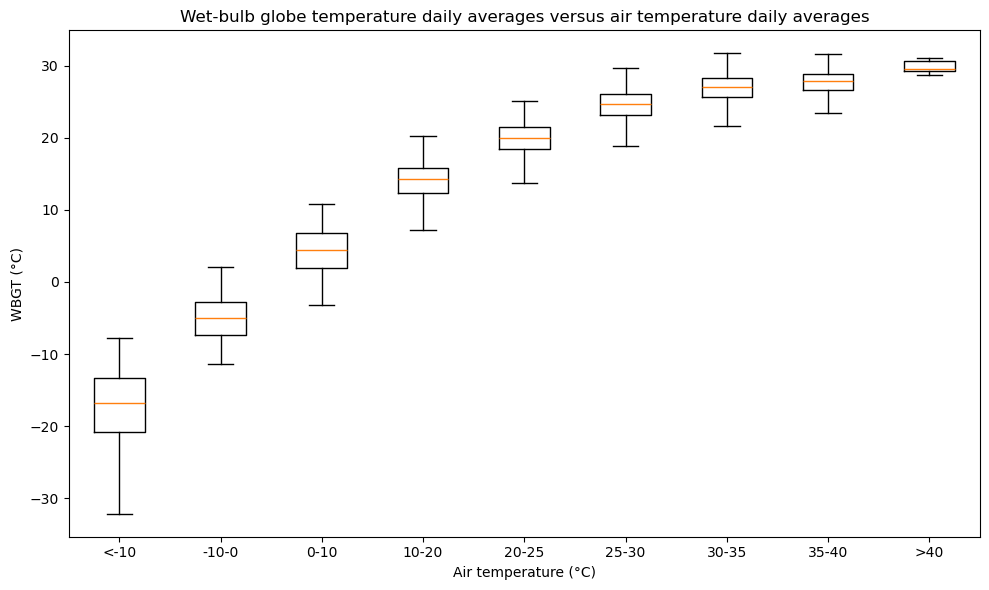

In [7]:
# --------------------------------------------------------------------
# 1. Compute daily mean values for each pixel
# --------------------------------------------------------------------
daily = two_temps.resample(time="1D").mean()

# Convert to dataframe, flatten spatial dimensions
df = daily[['t2m_c', 'wbgt_c']].to_dataframe().reset_index()

# Remove NaNs
df = df.dropna(subset=['t2m_c', 'wbgt_c'])

# --------------------------------------------------------------------
# 2. Define the same air-temperature bins as in your figure
# --------------------------------------------------------------------
bins = [-100, -10, 0, 10, 20, 25, 30, 35, 40, 100]
labels = ["<-10",  "-10-0", "0-10", "10-20", "20-25", "25-30", "30-35", 
          "35-40", ">40"]

df['T_bin'] = pd.cut(df['t2m_c'], bins=bins, labels=labels)

# --------------------------------------------------------------------
# 3. Group WB by temperature bin, prepare for boxplot
# --------------------------------------------------------------------
data_to_plot = [df.loc[df['T_bin'] == b, 'wbgt_c'].values for b in labels]

# --------------------------------------------------------------------
# 4. Plot boxplot
# --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(data_to_plot, showfliers=False)

ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel("Air temperature (°C)")
ax.set_ylabel("WBGT (°C)")
ax.set_title("Wet-bulb globe temperature daily averages versus air temperature daily averages")

plt.tight_layout()
plt.savefig("./3_output/img/wbgt_t2m_boxplots.png", dpi=300)
plt.show()